# SAMPIC waveform explorer — TRIUMF run 108 (fake-MIDAS full chain)

Multi-channel surface-muon data: the source is a `dat_to_root` ROOT file
(2.3M hits, 32 channels), converted with `converter/root_to_mid.py`
(first 20k tree entries, time-sorted, 100 ns gap clustering, first 1000
MIDAS events) and reconstructed through
`PIMidasSelector -> PITMidasSampic -> PIAOutputStream`.

Unlike run914 (single channel, 1 hit/event), these are genuine coincidence
events — mean 2.3, up to 7 hits per event.

Note: the source ROOT file in `data/TRIUMF/` is a symlink into
`~/Downloads`; mount that into the container (e.g. add
`-v /home/jlab/Downloads:/home/jlab/Downloads` to `run_container.sh`) for
the cross-check section to find it.

In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

WORKDIR = Path("/workdir")
REC_FILE = WORKDIR / "sampic-to-midas/output/run108_first1000_rec.root"
SOURCE_FILE = (WORKDIR / "data/TRIUMF"
               / "surfacemuons_down24percent_indtrig_s2Yslit_10_run108.root")
ENTRY_STOP = 20000      # tree slice used by root_to_mid.py
GAP_NS = 100.0
DT_NS = 1e3 / 6400      # 6400 MS/s -> 0.15625 ns / sample

# Okabe-Ito (colorblind-safe); one hue per role, fixed assignment
C_MAIN = "#0072B2"      # this chain
C_REF = "#D55E00"       # dat_to_root source
C_MUTED = "#999999"

plt.rcParams.update({
    "figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.25,
    "axes.spines.top": False, "axes.spines.right": False,
})

## Load the `rec` RNTuple

Same reader as the run914 notebook: uproot primary, PyROOT `RNTupleReader`
fallback; everything downstream consumes flat numpy arrays. The two hit-less
bookkeeping entries (loop priming + EOF probe) are reported separately.

In [2]:
def load_rec_uproot(path):
    import awkward as ak
    import uproot

    rn = uproot.open(path)["rec"]
    arr = rn.arrays(filter_name="*SampicEvent.hits*")
    hits = arr["_Event_SampicEvent"]["hits"]

    counts = ak.to_numpy(ak.num(hits, axis=1))
    flat = ak.flatten(hits, axis=1)
    wf = ak.fill_none(ak.pad_none(flat["corrected_waveform"], 64, axis=-1), 0.0)
    return {
        "n_events": len(counts),
        "counts": counts,
        "ev_index": np.repeat(np.arange(len(counts)), counts),
        "channel": ak.to_numpy(flat["channel"]),
        "hit_number": ak.to_numpy(flat["hit_number"]),
        "amplitude": ak.to_numpy(flat["amplitude"]),
        "baseline": ak.to_numpy(flat["baseline"]),
        "tot": ak.to_numpy(flat["tot_value"]),
        "time_instant": ak.to_numpy(flat["time_instant"]),
        "t0": ak.to_numpy(flat["first_cell_timestamp"]),
        "wf": ak.to_numpy(wf).astype(np.float32),
    }


def load_rec_pyroot(path):
    """Fallback via PyROOT RNTupleReader (needs main's setenv.sh sourced)."""
    import ROOT

    ROOT.gSystem.Load("libpi_unpacking")
    reader = ROOT.RNTupleReader.Open("rec", str(path))
    entry = reader.GetModel().GetDefaultEntry()
    get_event = entry.GetPtr["PIUnpack::Sampic::Event"]
    rows, wfs, counts = [], [], []
    for i in range(reader.GetNEntries()):
        reader.LoadEntry(i)
        ev = get_event("_Event_SampicEvent")
        counts.append(len(ev.hits))
        for h in ev.hits:
            rows.append((i, h.channel, h.hit_number, h.amplitude, h.baseline,
                         h.tot_value, h.time_instant, h.first_cell_timestamp))
            w = np.zeros(64, dtype=np.float32)
            w[:len(h.corrected_waveform)] = list(h.corrected_waveform)
            wfs.append(w)
    rows = np.array(rows)
    return {
        "n_events": len(counts),
        "counts": np.array(counts),
        "ev_index": rows[:, 0].astype(int),
        "channel": rows[:, 1].astype(int),
        "hit_number": rows[:, 2].astype(int),
        "amplitude": rows[:, 3].astype(np.float32),
        "baseline": rows[:, 4].astype(np.float32),
        "tot": rows[:, 5].astype(np.float32),
        "time_instant": rows[:, 6],
        "t0": rows[:, 7],
        "wf": np.vstack(wfs),
    }


try:
    D = load_rec_uproot(REC_FILE)
    print("loaded with uproot")
except Exception as exc:
    print(f"uproot path failed ({type(exc).__name__}: {exc}); trying PyROOT")
    D = load_rec_pyroot(REC_FILE)

n_empty = int((D["counts"] == 0).sum())
print(f"{D['n_events']} entries ({n_empty} hit-less bookkeeping), "
      f"{len(D['channel'])} hits, {len(set(D['channel']))} channels")

loaded with uproot
1002 entries (2 hit-less bookkeeping), 2316 hits, 26 channels


## Event structure: multiplicity and channel occupancy

The payoff of multi-channel data: real coincidences. Multiplicity is the
number of SAMPIC hits per 100 ns event; occupancy shows which channels
participate.

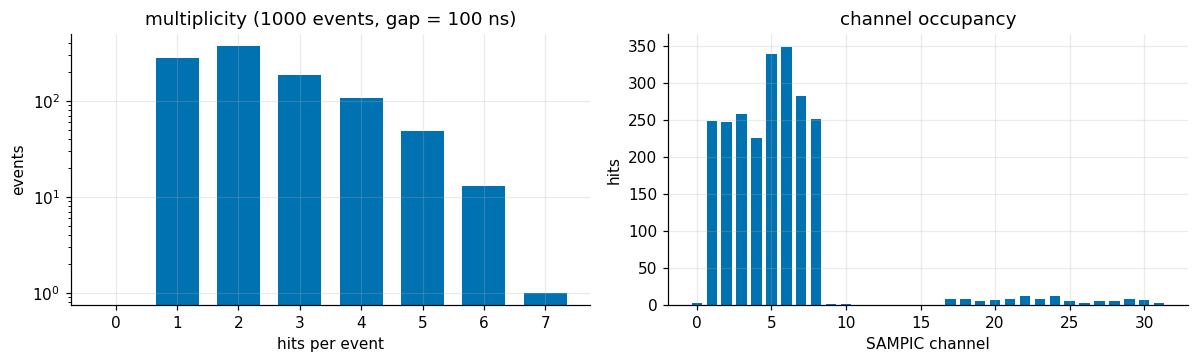

events with >= 2 hits: 719 (71.9%)


In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.4))
phys = D["counts"][D["counts"] > 0]
mult = np.bincount(phys)
ax1.bar(np.arange(len(mult)), mult, color=C_MAIN, width=0.7)
ax1.set_yscale("log")
ax1.set_xlabel("hits per event")
ax1.set_ylabel("events")
ax1.set_title(f"multiplicity ({len(phys)} events, gap = {GAP_NS:.0f} ns)")

occ = np.bincount(D["channel"], minlength=32)
ax2.bar(np.arange(32), occ, color=C_MAIN, width=0.7)
ax2.set_xlabel("SAMPIC channel")
ax2.set_ylabel("hits")
ax2.set_title("channel occupancy")
fig.tight_layout()
plt.show()

pairs = 0
for n in range(2, len(mult)):
    pairs += mult[n]
print(f"events with >= 2 hits: {pairs} ({pairs / len(phys):.1%})")

## Single-event waveforms

First 12 multi-hit events, all hits of an event overlaid on one panel —
these are the coincidences the ATAR reconstruction will consume.

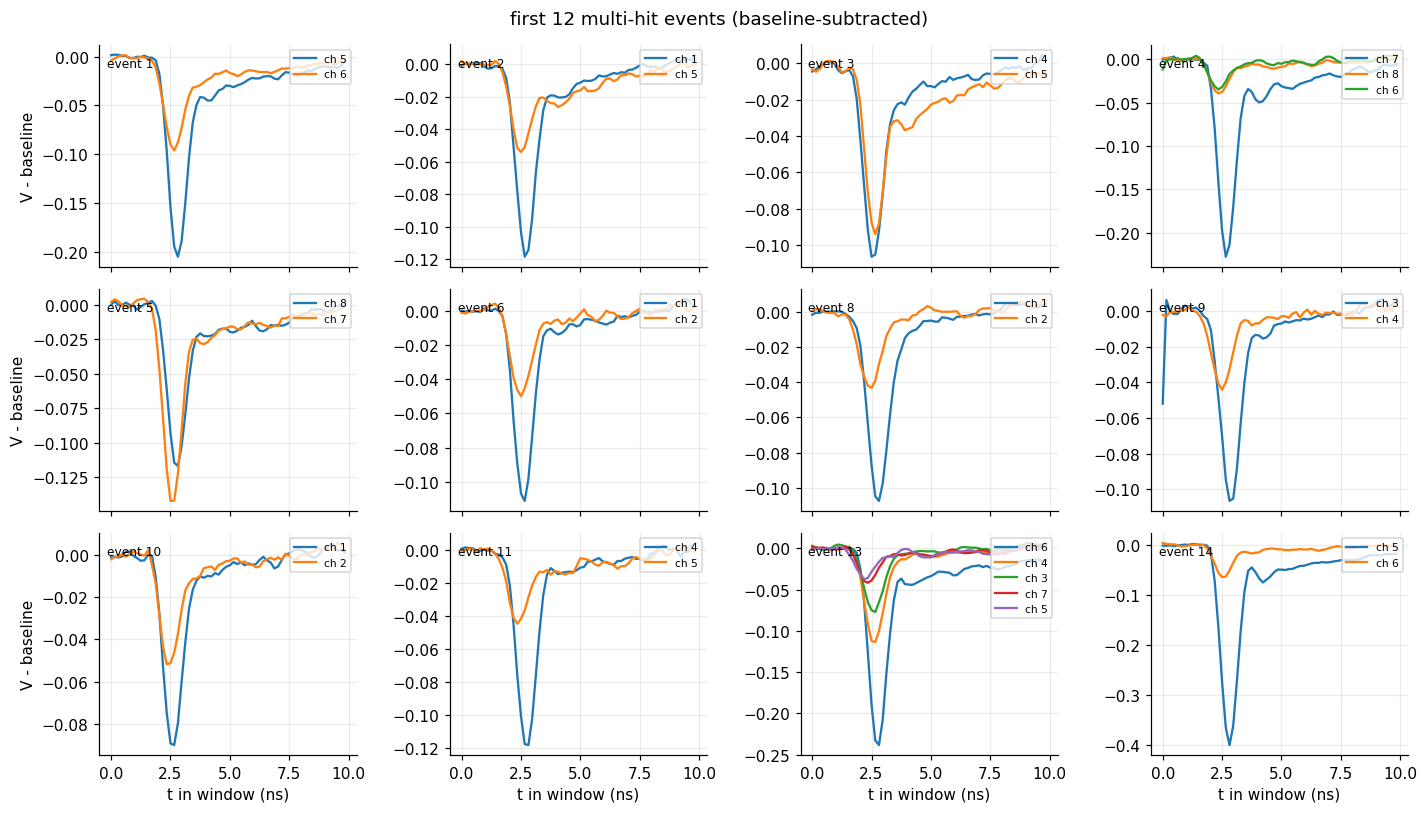

In [4]:
t_axis = np.arange(64) * DT_NS
multi_ev = np.flatnonzero(D["counts"] >= 2)[:12]
fig, axes = plt.subplots(3, 4, figsize=(13, 7.5), sharex=True)
for ax, ev in zip(axes.ravel(), multi_ev):
    sel = np.flatnonzero(D["ev_index"] == ev)
    for k in sel:
        ax.plot(t_axis, D["wf"][k] - D["wf"][k, 2:7].mean(), lw=1.5,
                label=f"ch {D['channel'][k]}")
    ax.legend(fontsize=7, loc="upper right")
    ax.annotate(f"event {ev}", xy=(0.03, 0.9), xycoords="axes fraction",
                fontsize=8)
for ax in axes[-1]:
    ax.set_xlabel("t in window (ns)")
for ax in axes[:, 0]:
    ax.set_ylabel("V - baseline")
fig.suptitle("first 12 multi-hit events (baseline-subtracted)")
fig.tight_layout()
plt.show()

## Waveform persistence

Baseline-subtracted voltage per sample index over all hits; the voltage
range is taken from the data quantiles.

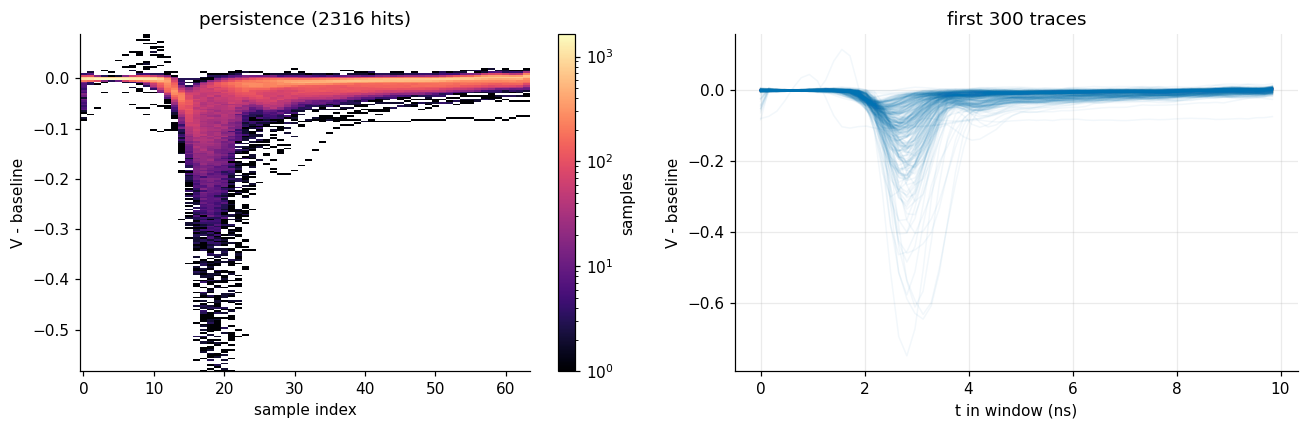

In [5]:
from matplotlib.colors import LogNorm

base_calc = D["wf"][:, 2:7].mean(axis=1)
dev = D["wf"] - base_calc[:, None]
lo, hi = np.quantile(dev, [0.001, 0.999])
pad = 0.15 * (hi - lo)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
sample_idx = np.tile(np.arange(64), len(dev))
h = ax1.hist2d(sample_idx, dev.ravel(),
               bins=[np.arange(65) - 0.5, np.linspace(lo - pad, hi + pad, 200)],
               cmap="magma", norm=LogNorm())
fig.colorbar(h[3], ax=ax1, label="samples")
ax1.set_xlabel("sample index")
ax1.set_ylabel("V - baseline")
ax1.set_title(f"persistence ({len(dev)} hits)")
ax1.grid(False)

for w in dev[:300]:
    ax2.plot(t_axis, w, color=C_MAIN, alpha=0.05, lw=1)
ax2.set_xlabel("t in window (ns)")
ax2.set_ylabel("V - baseline")
ax2.set_title("first 300 traces")
fig.tight_layout()
plt.show()

## Average waveforms and pulse template

Per-channel averages for the highest-occupancy channels, and the
amplitude-normalized template (peak scaled to +1 whatever the polarity) —
the shape input for pulse fitting.

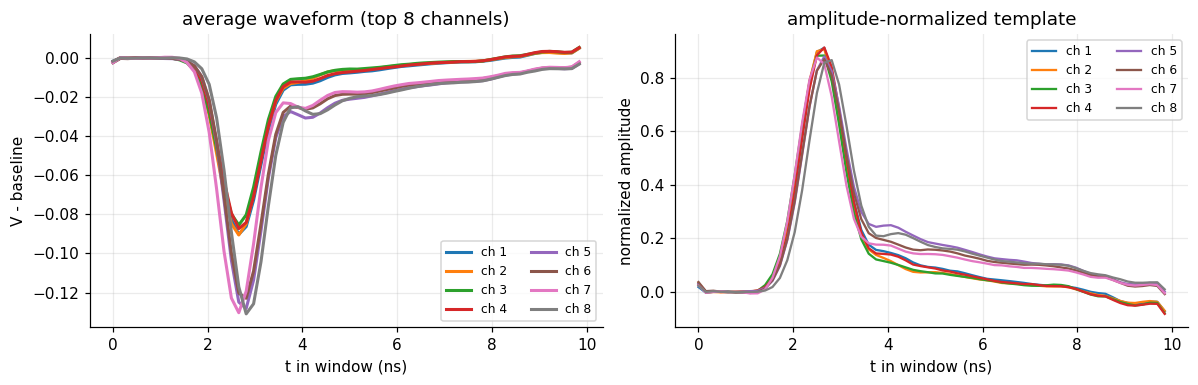

In [6]:
top = np.argsort(occ)[::-1][:8]
top = sorted(int(c) for c in top if occ[c] > 0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3.6))
for ch in top:
    sel = D["channel"] == ch
    ax1.plot(t_axis, dev[sel].mean(axis=0), lw=2, label=f"ch {ch}")

    sub = dev[sel][:, 3:62]
    amp_signed = np.take_along_axis(
        sub, np.abs(sub).argmax(axis=1)[:, None], axis=1)[:, 0]
    good = amp_signed != 0
    norm = dev[sel][good] / amp_signed[good, None]
    ax2.plot(t_axis, norm.mean(axis=0), lw=1.5, label=f"ch {ch}")
ax1.set_xlabel("t in window (ns)")
ax1.set_ylabel("V - baseline")
ax1.set_title(f"average waveform (top {len(top)} channels)")
ax1.legend(fontsize=8, ncol=2)
ax2.set_xlabel("t in window (ns)")
ax2.set_ylabel("normalized amplitude")
ax2.set_title("amplitude-normalized template")
ax2.legend(fontsize=8, ncol=2)
fig.tight_layout()
plt.show()

## Spectra

SAMPIC front-end measurements carried through the chain (not recomputed).

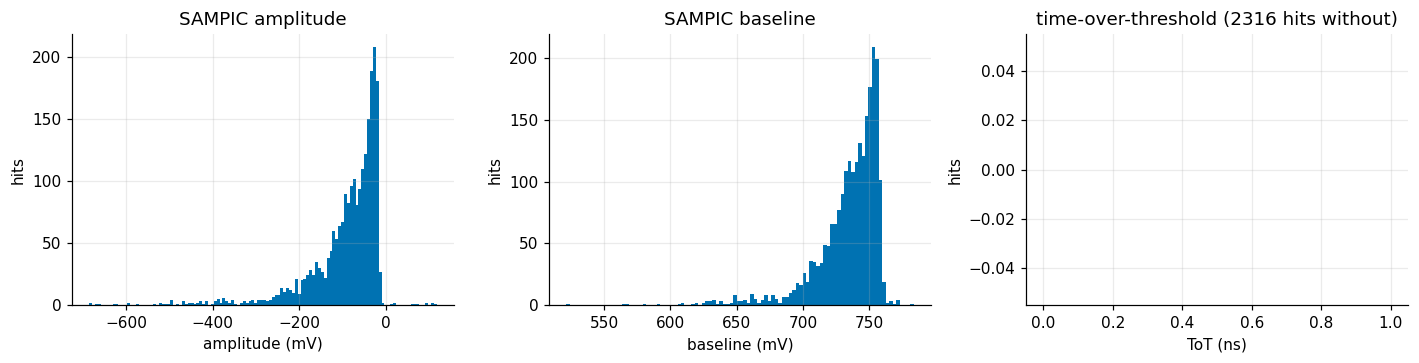

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))
axes[0].hist(D["amplitude"] * 1e3, bins=120, color=C_MAIN)
axes[0].set_xlabel("amplitude (mV)")
axes[0].set_title("SAMPIC amplitude")
axes[1].hist(D["baseline"] * 1e3, bins=100, color=C_MAIN)
axes[1].set_xlabel("baseline (mV)")
axes[1].set_title("SAMPIC baseline")
tot_ok = D["tot"] >= 0
axes[2].hist(D["tot"][tot_ok], bins=100, color=C_MAIN)
axes[2].set_xlabel("ToT (ns)")
axes[2].set_title(f"time-over-threshold ({(~tot_ok).sum()} hits without)")
for ax in axes:
    ax.set_ylabel("hits")
fig.tight_layout()
plt.show()

## Cross-check against the source tree

The source ROOT file *is* the `dat_to_root` output here, so the reference is
exact: re-read the same tree slice, apply the same stable `StartTime` sort,
and take the hits covered by the 1000 events (clusters are contiguous from
the start of the sorted slice). Every carried field and waveform sample must
match bitwise after the volts double -> float32 cast.

  [PASS] channel
  [PASS] hit_number
  [PASS] amplitude
  [PASS] baseline
  [PASS] t0
  [PASS] waveforms


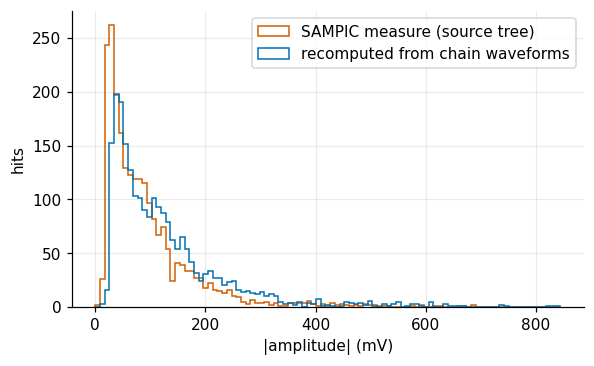

In [8]:
import sys
sys.path.insert(0, str(WORKDIR / "sampic-to-midas"))
import uproot
from converter.root_to_mid import load_hits

src = load_hits(uproot.open(SOURCE_FILE)["wfms"], None, ENTRY_STOP, 100000, False)
order = np.argsort(src["t0"], kind="stable")
src = src[order][:len(D["channel"])]

exp_wf = (src["wf"] / np.float64(1.0e4)).astype("<f4")
same = {
    "channel": np.array_equal(D["channel"], src["channel"]),
    "hit_number": np.array_equal(D["hit_number"], src["hit_number"]),
    "amplitude": np.array_equal(D["amplitude"].view("<u4"),
                                src["amplitude"].view("<u4")),
    "baseline": np.array_equal(D["baseline"].view("<u4"),
                               src["baseline"].view("<u4")),
    "t0": np.array_equal(D["t0"].view("<u8"), src["t0"].view("<u8")),
    "waveforms": np.array_equal(D["wf"].view("<u4"), exp_wf.view("<u4")),
}
for k, ok in same.items():
    print(f"  [{'PASS' if ok else 'FAIL'}] {k}")
assert all(same.values())

amp_sub = dev[:, 3:62]
amp_calc = np.take_along_axis(
    amp_sub, np.abs(amp_sub).argmax(axis=1)[:, None], axis=1)[:, 0]

fig, ax = plt.subplots(figsize=(6, 3.5))
bins = np.linspace(0, np.quantile(np.abs(amp_calc), 0.999) * 1e3, 100)
ax.hist(np.abs(src["amplitude"]) * 1e3, bins=bins, color=C_REF,
        histtype="step", lw=2, label="SAMPIC measure (source tree)")
ax.hist(np.abs(amp_calc) * 1e3, bins=bins, color=C_MAIN, histtype="step",
        lw=1.5, ls="--", label="recomputed from chain waveforms")
ax.set_xlabel("|amplitude| (mV)")
ax.set_ylabel("hits")
ax.legend()
plt.show()

## Event-building diagnostic

Consecutive-hit gaps in this slice: the in-event population (sub-ns to tens
of ns, coincident channels) is cleanly separated from the trigger-rate
population (~ms), so the 100 ns window sits in an empty valley.

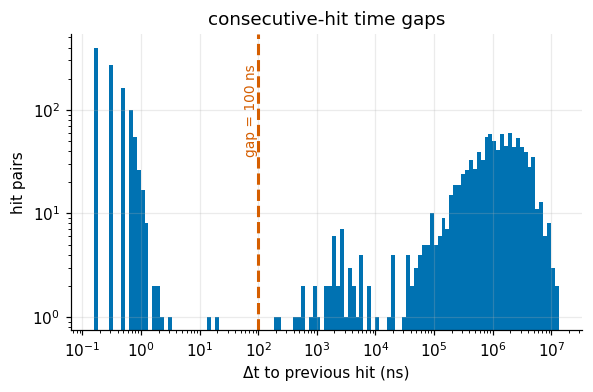

In [9]:
dt_hits = np.diff(np.sort(D["t0"]))
dt_hits = dt_hits[dt_hits > 0]

fig, ax = plt.subplots(figsize=(6, 3.5))
bins = np.logspace(np.log10(max(dt_hits.min(), 0.05)),
                   np.log10(dt_hits.max()), 120)
ax.hist(dt_hits, bins=bins, color=C_MAIN)
ax.axvline(GAP_NS, color=C_REF, lw=2, ls="--")
ax.annotate(f"gap = {GAP_NS:.0f} ns", xy=(GAP_NS, 0.9),
            xycoords=("data", "axes fraction"), rotation=90,
            va="top", ha="right", fontsize=9, color=C_REF)
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("Δt to previous hit (ns)")
ax.set_ylabel("hit pairs")
ax.set_title("consecutive-hit time gaps")
plt.show()

## Outlook

- **Channel mapping**: occupancy splits into a dense group (ch 1-8) and a
  sparse group (ch 17-30) — apply the channel -> strip/plane map to turn
  coincidences into geometry.
- **Coincidence reconstruction**: per-event channel patterns + relative
  `first_cell_timestamp` differences feed tracklet finding.
- **Energy / pulse fitting**: per-channel templates above; integrals vs the
  SAMPIC amplitude for calibration.
- **Scale up**: drop `--entry-stop` in `root_to_mid.py` to convert all 2.3M
  hits (~370 MB peak), then switch this notebook's loader to batched
  `uproot.iterate` reads.